In [12]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
CSV_PATH = "findex_pakistan_features_target.csv"

In [26]:
# ---------------------------------------------------------------------
# 1. Load cleaned data (output of script 01)
# ---------------------------------------------------------------------
data = pd.read_csv(CSV_PATH)
print(f"Loaded {data.shape[0]} rows, {data.shape[1]} columns")

Loaded 1000 rows, 24 columns


In [27]:
# ---------------------------------------------------------------------
# 2. Build X / y
#    Adoption Tier was constructed deterministically from account,
#    dig_account, anydigpayment, saved, and fin22a (see script 01).
#    Also drop account_fin and account_mob: in Findex, account is
#    essentially (account_fin OR account_mob), so predicting "Excluded"
#    (account=0) from "account_fin=0 AND account_mob=0" is close to
#    tautological, not a genuine finding -> confirmed by the earlier
#    run showing perfect 1.00 precision/recall on Excluded across every
#    model. Dropping these leaves genuinely independent access proxies
#    (con1 mobile phone ownership, internet_use) plus demographics to
#    do the real predictive work.
# ---------------------------------------------------------------------
drop_cols = ["adoption_tier", "adoption_tier_label",
             "account", "dig_account", "anydigpayment", "saved", "fin22a",
             "account_fin", "account_mob"]
X = data.drop(columns=drop_cols)
y = data["adoption_tier"]

print(f"\nFeatures used ({X.shape[1]}): {list(X.columns)}")
print(f"\nClass distribution:\n{y.value_counts().sort_index()}")



Features used (15): ['female', 'age', 'educ', 'inc_q', 'in_workforce', 'is_rural', 'con1', 'internet_use', 'merchantpay_dig', 'fin17b', 'fin17c', 'borrowed', 'fin22a_1', 'fin24a', 'fin24b']

Class distribution:
adoption_tier
0    682
1     21
2    101
3    196
Name: count, dtype: int64


In [28]:
# ---------------------------------------------------------------------
# 3. Train/test split (75/25, stratified since classes are imbalanced)
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")

# Scale features for Logistic Regression (tree models don't need this,
# but scaling doesn't hurt them either, so one scaler covers all)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train: 750 rows, Test: 250 rows


In [29]:
# ---------------------------------------------------------------------
# 4. Train models
# ---------------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                                                class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE,
                                             class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8,
                                             random_state=RANDOM_STATE,
                                             class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              random_state=RANDOM_STATE, eval_metric="mlogloss"),
}

results = []
fitted_models = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average="macro")
    f1_weighted = f1_score(y_test, preds, average="weighted")

    results.append({"Model": name, "Accuracy": acc, "F1 (macro)": f1_macro,
                     "F1 (weighted)": f1_weighted})
    fitted_models[name] = model

    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, preds, target_names=["Excluded", "Basic",
                                                               "Digitally Engaged", "Advanced"]))



Logistic Regression
                   precision    recall  f1-score   support

         Excluded       0.85      0.26      0.40       171
            Basic       0.00      0.00      0.00         5
Digitally Engaged       0.21      0.64      0.32        25
         Advanced       0.80      0.90      0.85        49

         accuracy                           0.42       250
        macro avg       0.47      0.45      0.39       250
     weighted avg       0.76      0.42      0.47       250


Decision Tree
                   precision    recall  f1-score   support

         Excluded       0.90      0.37      0.52       171
            Basic       0.02      0.20      0.04         5
Digitally Engaged       0.19      0.60      0.29        25
         Advanced       0.83      0.88      0.85        49

         accuracy                           0.49       250
        macro avg       0.48      0.51      0.42       250
     weighted avg       0.80      0.49      0.55       250


Random Forest

In [30]:
# ---------------------------------------------------------------------
# 5. Model comparison table
# ---------------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values("F1 (macro)", ascending=False)
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results_df.to_string(index=False))
results_df.to_csv("model_comparison.csv", index=False)

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest model by F1 (macro): {best_model_name}")


MODEL COMPARISON
              Model  Accuracy  F1 (macro)  F1 (weighted)
      Random Forest     0.708    0.486268       0.737429
            XGBoost     0.800    0.480934       0.781240
      Decision Tree     0.488    0.424439       0.553827
Logistic Regression     0.420    0.391985       0.472668

Best model by F1 (macro): Random Forest


Saved: confusion_matrix_best_model.png


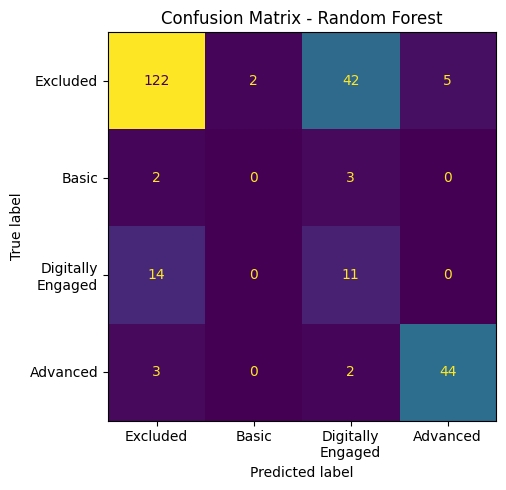

In [31]:
# ---------------------------------------------------------------------
# 6. Confusion matrix for the best model
# ---------------------------------------------------------------------
best_model = fitted_models[best_model_name]
X_test_for_best = X_test_scaled if best_model_name == "Logistic Regression" else X_test
preds_best = best_model.predict(X_test_for_best)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, preds_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Excluded", "Basic", "Digitally\nEngaged", "Advanced"])
disp.plot(ax=ax, cmap="viridis", colorbar=False)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix_best_model.png", dpi=150, bbox_inches="tight")
print("Saved: confusion_matrix_best_model.png")
plt.show()

Saved: feature_importance.png


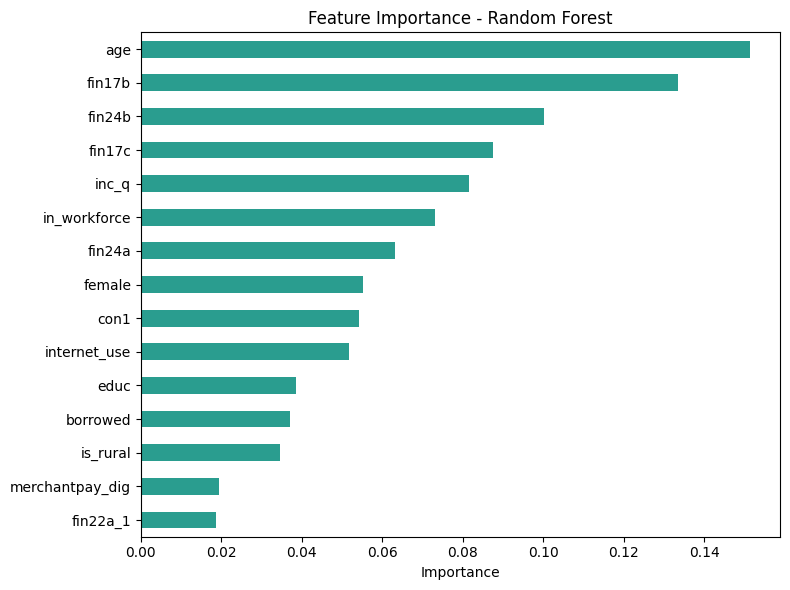

In [32]:
# ---------------------------------------------------------------------
# 7. Feature importance (tree-based models only)
# ---------------------------------------------------------------------
if best_model_name in ["Decision Tree", "Random Forest", "XGBoost"]:
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 6))
    importances.head(15).plot(kind="barh", ax=ax, color="#2a9d8f")
    ax.invert_yaxis()
    ax.set_title(f"Feature Importance - {best_model_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    print("Saved: feature_importance.png")
    plt.show()


Computing SHAP values...
Saved: shap_summary.png


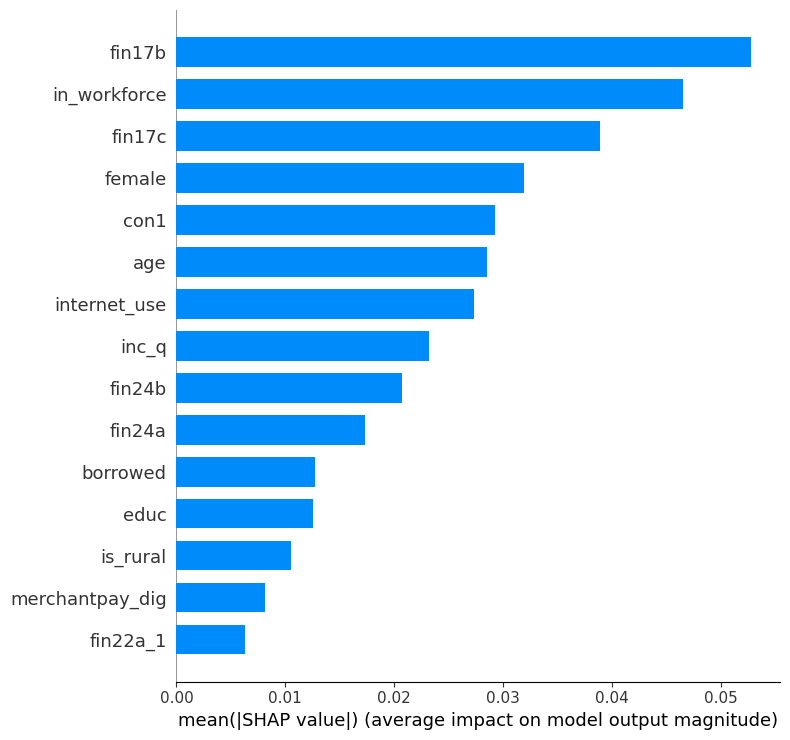


Week 2 complete. Outputs saved:
  - model_comparison.csv
  - confusion_matrix_best_model.png
  - feature_importance.png (if best model is tree-based)
  - shap_summary.png


In [ ]:
# ---------------------------------------------------------------------
# 8. SHAP explainability on the best model
#    TreeExplainer for tree models (fast, exact); falls back to
#    LinearExplainer if Logistic Regression wins.
# ---------------------------------------------------------------------
print("\nComputing SHAP values...")

if best_model_name == "Logistic Regression":
    explainer = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
    X_test_display = pd.DataFrame(X_test_scaled, columns=X.columns)
else:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    X_test_display = X_test

# shap_values can come back in different shapes depending on shap
# version/model:
#   - list of arrays, one per class, each (n_samples, n_features)
#   - 3D ndarray (n_samples, n_features, n_classes)  <- newer shap
#   - 2D ndarray (n_samples, n_features)              <- binary/regression
# Passing the raw 3D case straight to summary_plot silently misfires:
# it gets interpreted as feature-interaction data instead of per-class
# SHAP values, producing a confusing n_classes x n_classes grid
# mislabeled with feature names. Handle all three explicitly.
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    shap.summary_plot(mean_abs_shap, X_test_display, plot_type="bar", show=False)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    mean_abs_shap = np.abs(shap_values).mean(axis=2)
    shap.summary_plot(mean_abs_shap, X_test_display, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_test_display, show=False)

plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
print("Saved: shap_summary.png")
plt.show()

print("\nWeek 2 complete. Outputs saved:")
print("  - model_comparison.csv")
print("  - confusion_matrix_best_model.png")
print("  - feature_importance.png (if best model is tree-based)")
print("  - shap_summary.png")